In [2]:
%matplotlib inline

In [3]:
from collections import defaultdict
from __future__ import annotations
# In standard Python, dictionaries are incredibly strict. If you ask a standard dictionary for a key it has never seen before,
#  it instantly halts your program and throws a KeyError. A defaultdict fixes this by automatically creating that missing key on the fly
#  and assigning it a default starting value of your choice.
import matplotlib.pyplot as plt# Drawing Plots
from matplotlib.patches import Patch # Drawing shapes
import numpy as np # Data and array manipulation
import seaborn as sns # Data Visualization
from tqdm import tqdm # Shows the loader Bar, Progress
import gymnasium as gym
from IPython.display import clear_output
import time

In [4]:
for i , _ in enumerate(gym.envs.registry): # Available Environments
    print(f"Env {i+1} - {_}")

Env 1 - CartPole-v0
Env 2 - CartPole-v1
Env 3 - MountainCar-v0
Env 4 - MountainCarContinuous-v0
Env 5 - Pendulum-v1
Env 6 - Acrobot-v1
Env 7 - phys2d/CartPole-v0
Env 8 - phys2d/CartPole-v1
Env 9 - phys2d/Pendulum-v0
Env 10 - LunarLander-v3
Env 11 - LunarLanderContinuous-v3
Env 12 - BipedalWalker-v3
Env 13 - BipedalWalkerHardcore-v3
Env 14 - CarRacing-v3
Env 15 - Blackjack-v1
Env 16 - FrozenLake-v1
Env 17 - FrozenLake8x8-v1
Env 18 - CliffWalking-v1
Env 19 - CliffWalkingSlippery-v1
Env 20 - Taxi-v4
Env 21 - tabular/Blackjack-v0
Env 22 - tabular/CliffWalking-v0
Env 23 - Reacher-v2
Env 24 - Reacher-v4
Env 25 - Reacher-v5
Env 26 - Pusher-v2
Env 27 - Pusher-v4
Env 28 - Pusher-v5
Env 29 - InvertedPendulum-v2
Env 30 - InvertedPendulum-v4
Env 31 - InvertedPendulum-v5
Env 32 - InvertedDoublePendulum-v2
Env 33 - InvertedDoublePendulum-v4
Env 34 - InvertedDoublePendulum-v5
Env 35 - HalfCheetah-v2
Env 36 - HalfCheetah-v3
Env 37 - HalfCheetah-v4
Env 38 - HalfCheetah-v5
Env 39 - Hopper-v2
Env 40 - Ho

In [12]:
env = gym.make('Blackjack-v1', sab = True, render_mode = 'rgb_array') # 'rgb_array' -> only gives array values
print(env.action_space)
print(env.observation_space)

Discrete(2)
Tuple(Discrete(32), Discrete(11), Discrete(2))


# Observing the Environment

In [6]:
# reset the environment to get the first observation
done = False
observation, info = env.reset()
# Observation structure: (16,9,False) -> (Player's Sum, Value of Dealer's Face Up Card, Usuable Ace)
print(info)

{}


In [7]:
action = env.action_space.sample() # Sampling a random action from all valid action
observation, reward, terminated, truncated, info = env.step(action) # Executing the action in the environment and receieve info after taking the step

observation = (24,10,False)
reward = -1.0
terminated = True
truncated  = False
info = {}
print(action) # Prints 0 or 1

1


Once ``terminated = True`` or ``truncated=True``, we should stop the current episode and begin a new one with ``env.reset()``. If you continue executing actions without resetting the environment, it still responds but the output won’t be useful for training (it might even be harmful if the agent learns on invalid data).

# Epsilon - Greedy Strategy Approach

In [ ]:
class BlackJackAgent:
    def __init__(self, learning_rate : float, initial_epsilon : float, epsilon_decay : float, final_epsilon : float, discount_factor : float = 0.95):
        self.q_values = defaultdict(lambda:np.zeros(env.action_space.n)) # initialize an empty dictionary of state-action values if not seen before, 'env.action_space.n' is the number of elements in the action space
        # 'env.action_space.n' -> returns 2. So [0,0] if state action pair is not in the Q-table
        # structure of the dictionary: {(16,9,False):[0,0], (10,12,True):[-0.4,0.6] ... }
        self.lr = learning_rate
        self.discount_factor = discount_factor
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.training_error = []

    def get_action(self, obs:tuple[int,int,bool]): # OUR POLICY
        
        # Selects the random action with 'epsilon' probability and the greedy action with '1-epsilon' probability. 
        if np.random.random() < self.epsilon: # Random Action
            return env.action_space.sample()
        else:
            return int(np.argmax(self.q_values[obs])) # 'self.q_values[obs]' gives the 'value' in the key-value pair and 'np.argmax' gives the index of the action with the better estimate
    
    def td_update(self, obs:tuple[int,int,bool], action:int, reward:float, terminated:bool, next_obs:tuple[int,int,bool]): # This function is used to update the Q-value of the action
        if terminated == False:
            temporal_difference =  ((reward + self.discount_factor * np.max(self.q_values[next_obs])) - self.q_values[obs][action])
        else:
            temporal_difference =  ((reward + self.discount_factor * 0) - self.q_values[obs][action])

        self.q_values[obs][action] += self.lr * temporal_difference
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

The ``Q-value function`` is used to calculate the optimal action in each state.

# Training Loop

In [9]:
# RUN THIS CELL ONLY ONCE in a Kernel instance
# Hyperparameters
learning_rate = 0.01
n_episodes = 100000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2) # reduce the exploration over time
final_epsilon = 0.1

agent = BlackJackAgent(learning_rate = learning_rate, initial_epsilon = start_epsilon, epsilon_decay = epsilon_decay, final_epsilon = final_epsilon) # Agent is initialized
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)


# Single Episode Run

  0%|          | 0/1 [00:00<?, ?it/s]

Episode: 1
Seqence: 1
Observation (12, 6, 0)
Action taken: Hit


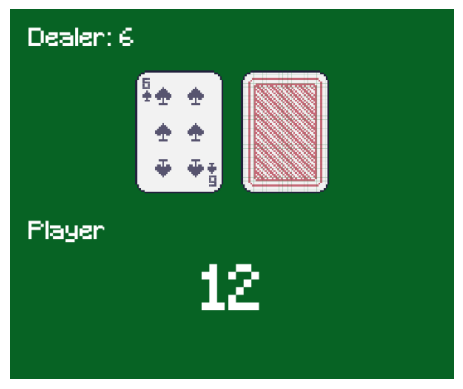

Next Observation (22, 6, 0)
Reward -1.0
Terminated True
Truncated False


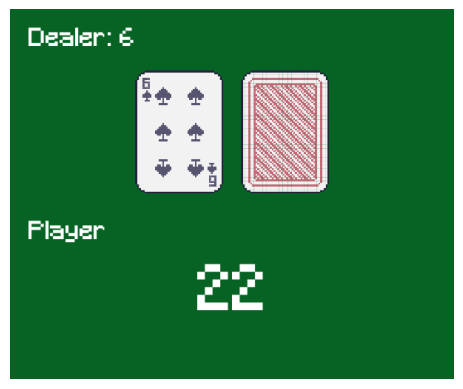

100%|██████████| 1/1 [00:00<00:00,  1.55it/s]


In [10]:
for episode in tqdm(range(1)):
    obs, info = env.reset()
    done = False
    print(f"Episode: {episode + 1}")
    # clear_output()
    # play one episode

    counter = 1 # for the number of sequence in an episode
    while not done:

        print(f"Seqence: {counter}")
        print(f"Observation {obs}")
        action = agent.get_action(obs)
        if action == 0:
            print("Action taken: Stick")
        else:
            print('Action taken: Hit')

        
        # Rendering Image BEFORE the step function
        frame = env.render()
        plt.imshow(frame)
        plt.axis('off')
        plt.show()
        

        next_obs, reward, terminated, truncated, info = env.step(action)
        print(f"Next Observation {next_obs}")
        print(f"Reward {reward}")
        print(f"Terminated {terminated}")
        print(f"Truncated {truncated}")

        # td_update the agent
        agent.td_update(obs, action, reward, terminated, next_obs)


        # Rendering Image AFTER the step function    
        frame = env.render()
        plt.imshow(frame)
        plt.axis('off')
        plt.show()

        counter += 1
        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon() # Reducing the exploration in every episode

# 10 Episode Run

  0%|          | 0/10 [00:00<?, ?it/s]

Episode: 1
Seqence: 1
Observation (11, 8, 0)
Action taken: Stick


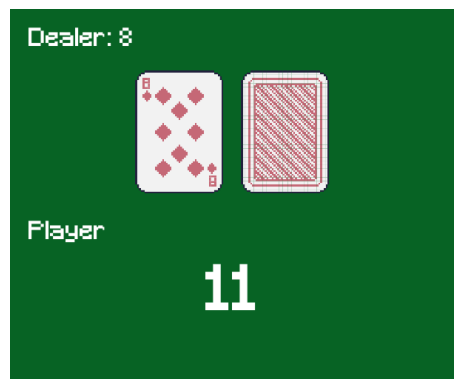

Next Observation (11, 8, 0)
Reward -1.0
Terminated True
Truncated False


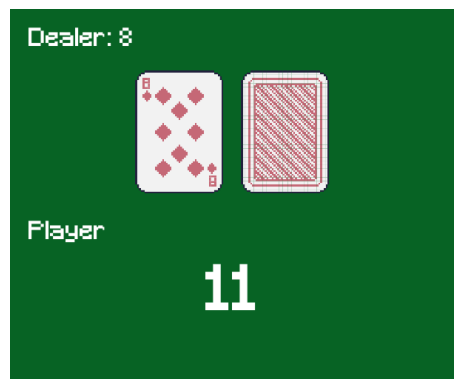

 10%|█         | 1/10 [00:00<00:01,  6.61it/s]

Episode: 2
Seqence: 1
Observation (9, 1, 0)
Action taken: Hit


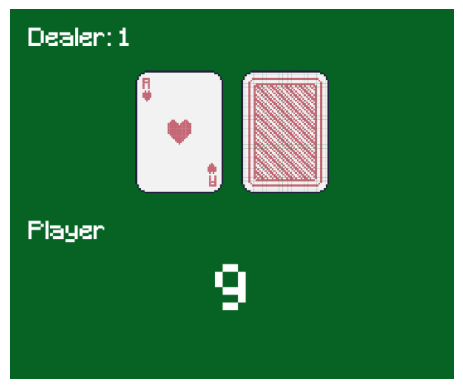

Next Observation (19, 1, 0)
Reward 0.0
Terminated False
Truncated False


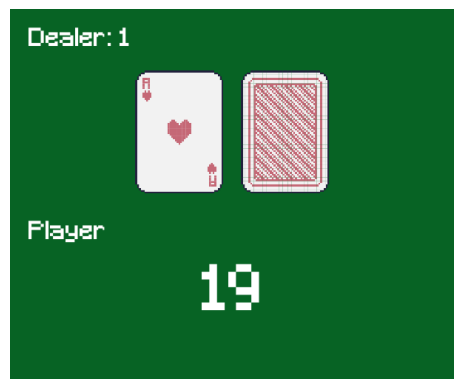

Seqence: 2
Observation (19, 1, 0)
Action taken: Hit


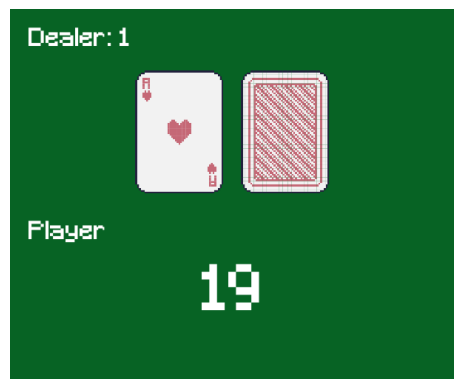

Next Observation (27, 1, 0)
Reward -1.0
Terminated True
Truncated False


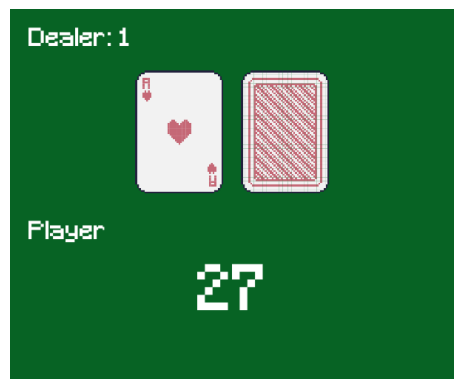

 20%|██        | 2/10 [00:00<00:02,  3.37it/s]

Episode: 3
Seqence: 1
Observation (18, 10, 0)
Action taken: Stick


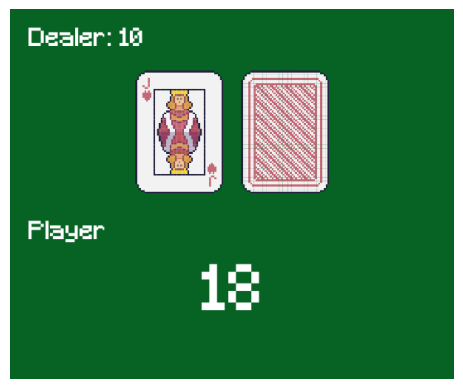

Next Observation (18, 10, 0)
Reward -1.0
Terminated True
Truncated False


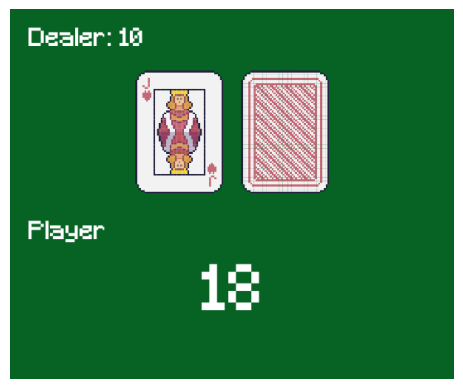

 30%|███       | 3/10 [00:00<00:01,  4.31it/s]

Episode: 4
Seqence: 1
Observation (20, 10, 0)
Action taken: Stick


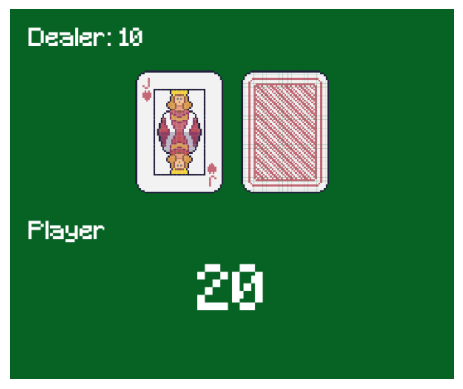

Next Observation (20, 10, 0)
Reward 1.0
Terminated True
Truncated False


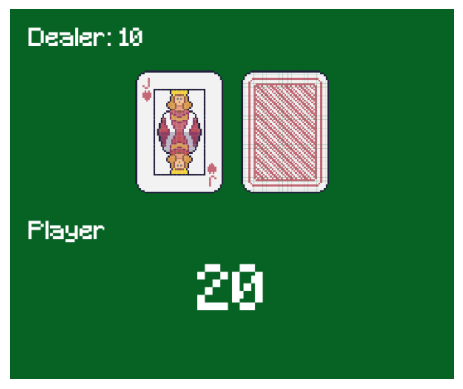

 40%|████      | 4/10 [00:00<00:01,  4.84it/s]

Episode: 5
Seqence: 1
Observation (19, 10, 1)
Action taken: Hit


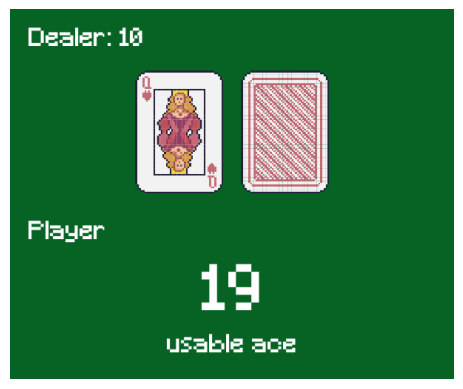

Next Observation (13, 10, 0)
Reward 0.0
Terminated False
Truncated False


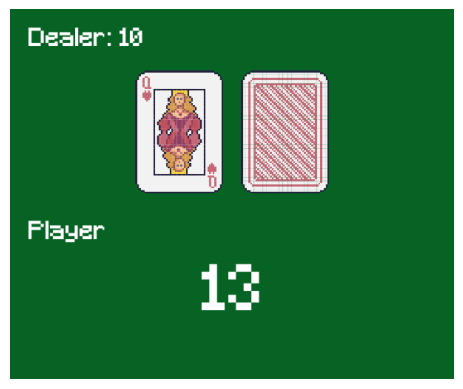

Seqence: 2
Observation (13, 10, 0)
Action taken: Stick


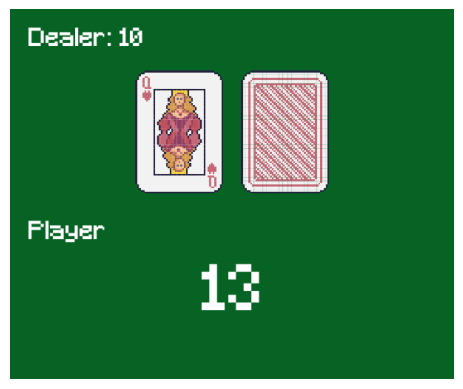

Next Observation (13, 10, 0)
Reward -1.0
Terminated True
Truncated False


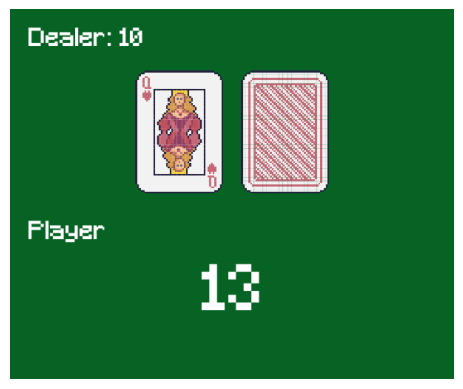

 50%|█████     | 5/10 [00:01<00:01,  4.12it/s]

Episode: 6
Seqence: 1
Observation (7, 10, 0)
Action taken: Stick


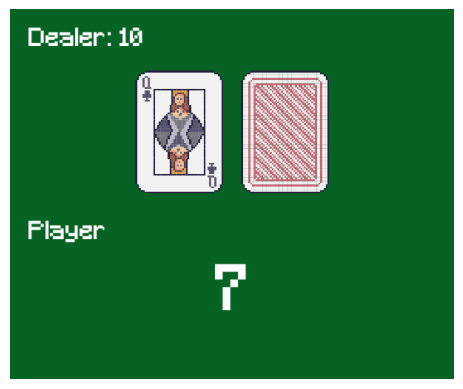

Next Observation (7, 10, 0)
Reward -1.0
Terminated True
Truncated False


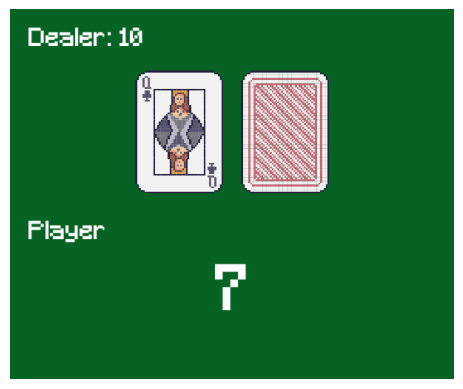

 60%|██████    | 6/10 [00:01<00:00,  4.66it/s]

Episode: 7
Seqence: 1
Observation (17, 1, 0)
Action taken: Stick


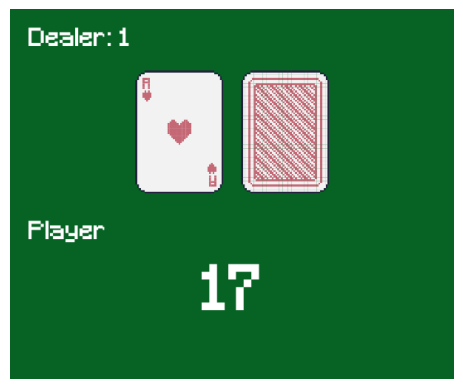

Next Observation (17, 1, 0)
Reward 1.0
Terminated True
Truncated False


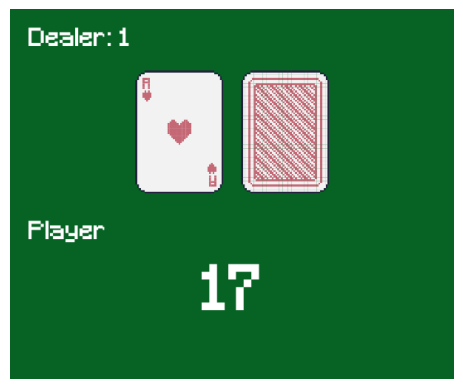

 70%|███████   | 7/10 [00:01<00:00,  5.00it/s]

Episode: 8
Seqence: 1
Observation (19, 10, 0)
Action taken: Stick


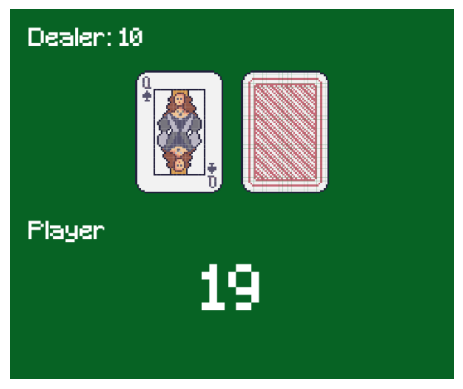

Next Observation (19, 10, 0)
Reward 1.0
Terminated True
Truncated False


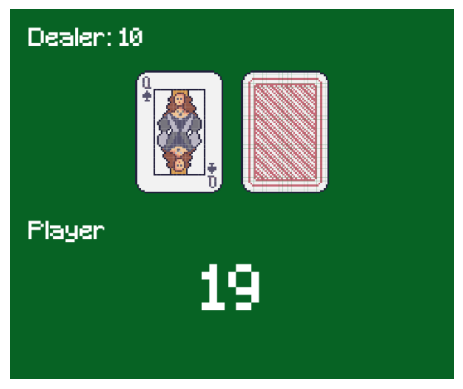

 80%|████████  | 8/10 [00:01<00:00,  5.29it/s]

Episode: 9
Seqence: 1
Observation (11, 3, 0)
Action taken: Hit


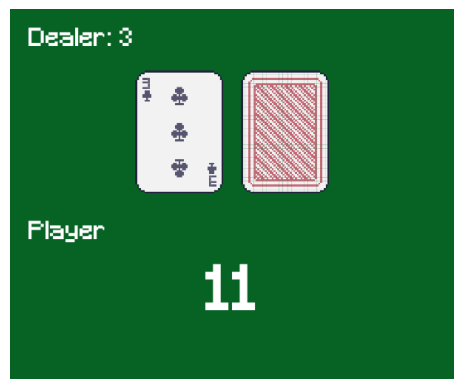

Next Observation (14, 3, 0)
Reward 0.0
Terminated False
Truncated False


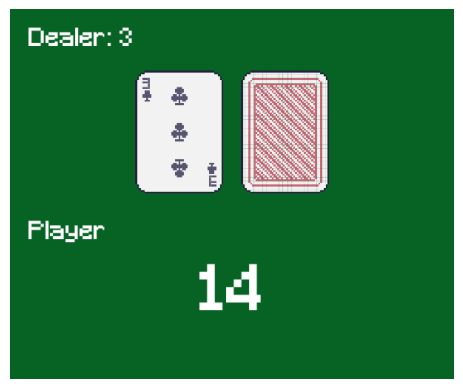

Seqence: 2
Observation (14, 3, 0)
Action taken: Hit


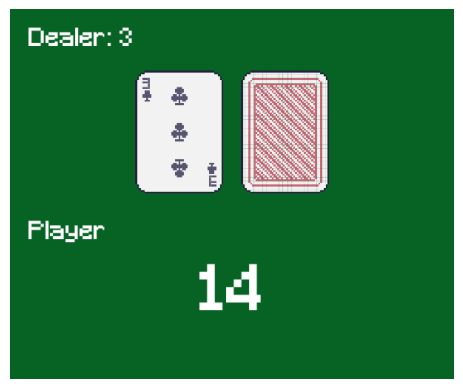

Next Observation (21, 3, 0)
Reward 0.0
Terminated False
Truncated False


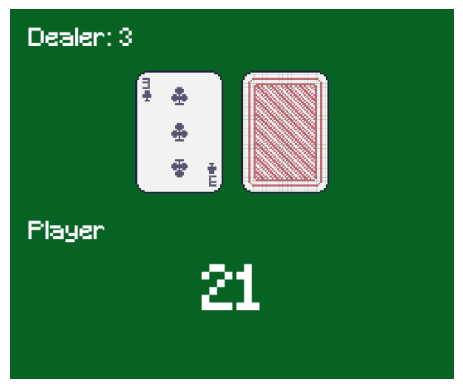

Seqence: 3
Observation (21, 3, 0)
Action taken: Stick


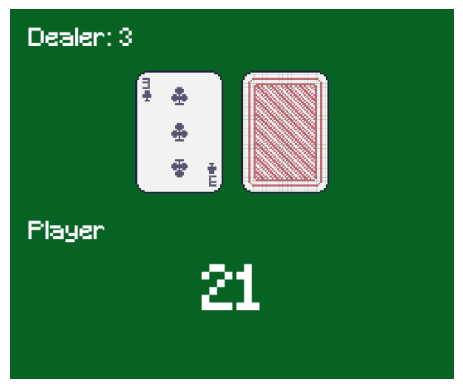

Next Observation (21, 3, 0)
Reward 1.0
Terminated True
Truncated False


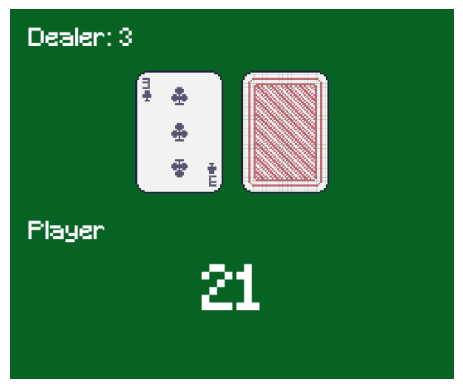

 90%|█████████ | 9/10 [00:02<00:00,  3.51it/s]

Episode: 10
Seqence: 1
Observation (20, 10, 0)
Action taken: Stick


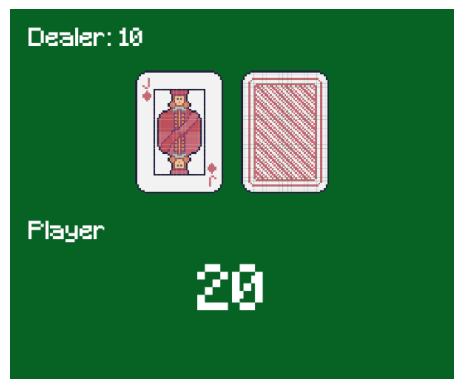

Next Observation (20, 10, 0)
Reward 0.0
Terminated True
Truncated False


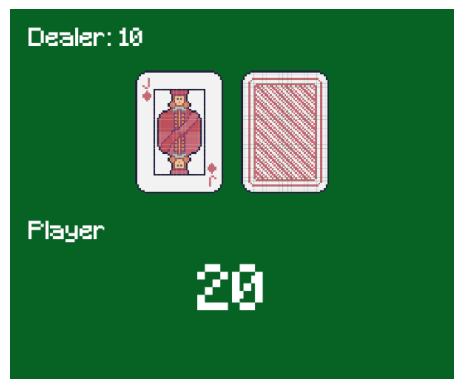

100%|██████████| 10/10 [00:02<00:00,  4.27it/s]


In [11]:
for episode in tqdm(range(10)):
    obs, info = env.reset()
    done = False
    print(f"Episode: {episode + 1}")
    # clear_output()
    # play one episode

    counter = 1 # for the number of sequence in an episode
    while not done:

        print(f"Seqence: {counter}")
        print(f"Observation {obs}")
        action = agent.get_action(obs)
        if action == 0:
            print("Action taken: Stick")
        else:
            print('Action taken: Hit')

        
        # Rendering Image BEFORE the step function
        frame = env.render()
        plt.imshow(frame)
        plt.axis('off')
        plt.show()
        

        next_obs, reward, terminated, truncated, info = env.step(action)
        print(f"Next Observation {next_obs}")
        print(f"Reward {reward}")
        print(f"Terminated {terminated}")
        print(f"Truncated {truncated}")

        # update the agent
        agent.td_update(obs, action, reward, terminated, next_obs)


        # Rendering Image AFTER the step function    
        frame = env.render()
        plt.imshow(frame)
        plt.axis('off')
        plt.show()

        counter += 1
        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon() # Reducing the exploration in every episode

# 100,000 Training Episodes

In [ ]:
n_episodes = 100000
for episode in tqdm(range(n_episodes)):
    obs, info = env.reset()
    done = False

    # play one episode
    while not done:
        action = agent.get_action(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)

        # update the agent
        agent.td_update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()

100%|██████████| 100000/100000 [00:16<00:00, 6249.45it/s]


# Visualize the training of the Agent

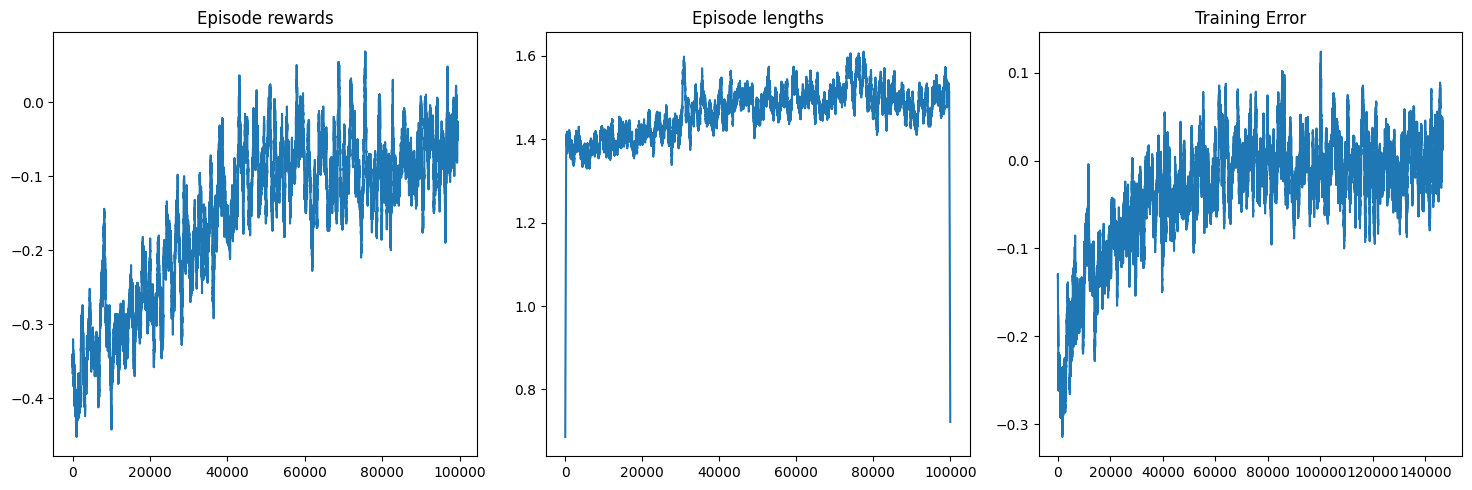

In [12]:
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(15, 5))


axs[0].set_title("Episode rewards")
# compute and assign a rolling average of the data to provide a smoother graph
reward_moving_average = (
    np.convolve(
        np.array(env.return_queue).flatten(), np.ones(rolling_length), mode="valid"
    )
    / rolling_length
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)


axs[1].set_title("Episode lengths")
length_moving_average = (
    np.convolve(
        np.array(env.length_queue).flatten(), np.ones(rolling_length), mode="same"
    )
    / rolling_length
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)




axs[2].set_title("Training Error")
training_error_moving_average = (
    np.convolve(np.array(agent.training_error), np.ones(rolling_length), mode="same")
    / rolling_length
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
plt.tight_layout()
plt.show()

# Visulaizing the Policy

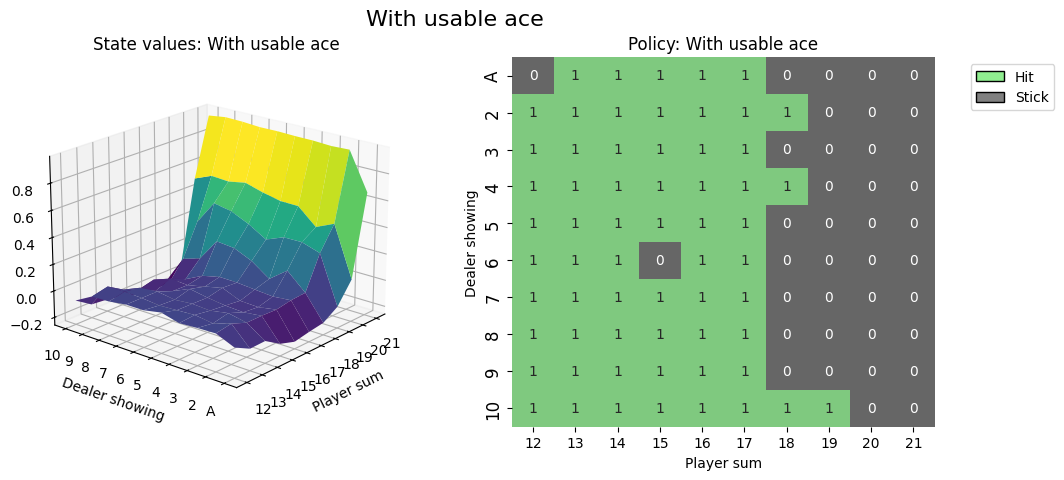

In [15]:
def create_grids(agent, usable_ace=False):
    """Create value and policy grid given an agent."""
    # convert our state-action values to state values
    # and build a policy dictionary that maps observations to actions
    state_value = defaultdict(float)
    policy = defaultdict(int)
    for obs, action_values in agent.q_values.items():
        state_value[obs] = float(np.max(action_values))
        policy[obs] = int(np.argmax(action_values))

    player_count, dealer_count = np.meshgrid(
        # players count, dealers face-up card
        np.arange(12, 22),
        np.arange(1, 11),
    )

    # create the value grid for plotting
    value = np.apply_along_axis(
        lambda obs: state_value[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    value_grid = player_count, dealer_count, value

    # create the policy grid for plotting
    policy_grid = np.apply_along_axis(
        lambda obs: policy[(obs[0], obs[1], usable_ace)],
        axis=2,
        arr=np.dstack([player_count, dealer_count]),
    )
    return value_grid, policy_grid


def create_plots(value_grid, policy_grid, title: str):
    """Creates a plot using a value and policy grid."""
    # create a new figure with 2 subplots (left: state values, right: policy)
    player_count, dealer_count, value = value_grid
    fig = plt.figure(figsize=plt.figaspect(0.4))
    fig.suptitle(title, fontsize=16)

    # plot the state values
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_surface(
        player_count,
        dealer_count,
        value,
        rstride=1,
        cstride=1,
        cmap="viridis",
        edgecolor="none",
    )
    plt.xticks(range(12, 22), range(12, 22))
    plt.yticks(range(1, 11), ["A"] + list(range(2, 11)))
    ax1.set_title(f"State values: {title}")
    ax1.set_xlabel("Player sum")
    ax1.set_ylabel("Dealer showing")
    ax1.zaxis.set_rotate_label(False)
    ax1.set_zlabel("Value", fontsize=14, rotation=90)
    ax1.view_init(20, 220)

    # plot the policy
    fig.add_subplot(1, 2, 2)
    ax2 = sns.heatmap(policy_grid, linewidth=0, annot=True, cmap="Accent_r", cbar=False)
    ax2.set_title(f"Policy: {title}")
    ax2.set_xlabel("Player sum")
    ax2.set_ylabel("Dealer showing")
    ax2.set_xticklabels(range(12, 22))
    ax2.set_yticklabels(["A"] + list(range(2, 11)), fontsize=12)

    # add a legend
    legend_elements = [
        Patch(facecolor="lightgreen", edgecolor="black", label="Hit"),
        Patch(facecolor="grey", edgecolor="black", label="Stick"),
    ]
    ax2.legend(handles=legend_elements, bbox_to_anchor=(1.3, 1))
    return fig


# state values & policy with usable ace (ace counts as 11)
value_grid, policy_grid = create_grids(agent, usable_ace=True)
fig1 = create_plots(value_grid, policy_grid, title="With usable ace")
plt.show()

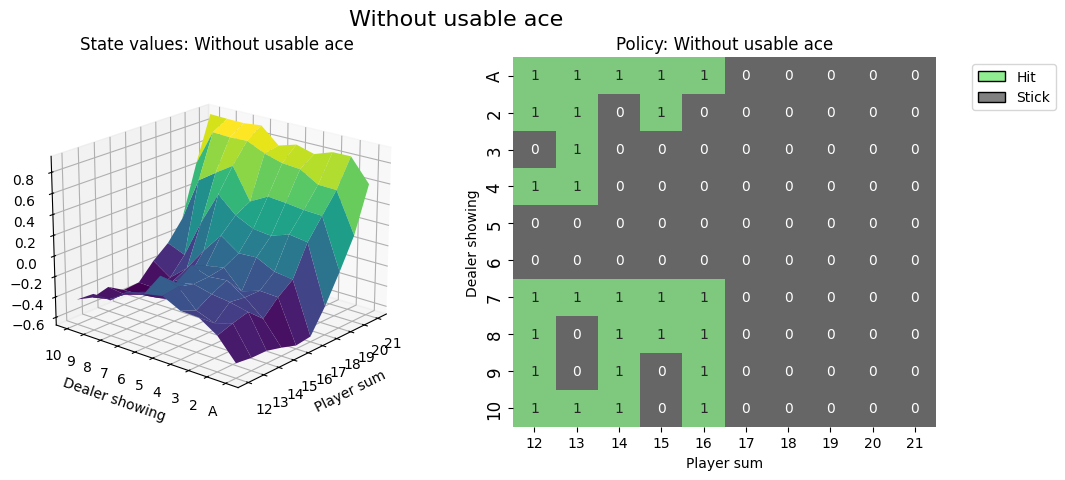

In [16]:
# state values & policy without usable ace (ace counts as 1)
value_grid, policy_grid = create_grids(agent, usable_ace=False)
fig2 = create_plots(value_grid, policy_grid, title="Without usable ace")
plt.show()